# STAT 7220 - Homework 4
## Mixed Effects Experiments
## Dr. Austin Brown
## Due Date: April 24, 2026

## Instructions:

The International Paralympic Committee is evaluating two new carbon-fiber blade designs: Model A (Aerostep) and Model B (Bionic-Flex). The goal is to determine if either new design yields meaningfully different 100-meter sprint times among T64 sprinters. Note, a T64 sprinter is an athlete with an absence of one leg below the knee.

Because sprint performance is highly dependent on an individual athlete’s biomechanics, muscle composition, and training level, the research team has recruited 5 professional T64 sprinters to participate in a study. Each athlete will perform three timed trials with both of the blade types in a randomized order. In this experiment, we want to control for the variability of individual athletes, but we are most interested in comparing the mean differences between the two blade designs. The results of this experiment are contained in the `Paralympic_Blade_Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

- This experiment aims to find out whether two novel carbon-fiber blade designs, Model A (Aerostep) and Model B (Bionic-Flex), differ statistically in 100-meter sprint performance. The study used a within-subjects (repeated measurements) design due to the highly unique nature of performance. Accounting for the inherent differences in biomechanics, training, and muscle composition among athletes by using the same five T64 sprinters to test both blade types over several trials makes it possible to more precisely determine how the blade design affects mean sprint timings.

2.  Specify the outcome variable and how it is measured.

- **DV:** Sprint_Time

- Mesured by recording a 100-meter sprint time in seconds.

3.  Specify the independent variables, including which is fixed and which is random. What lurking variables may be present?

- **IVs:** Blade_Type (Fixed) and Athlete_ID (Random)

- Different lurking variables exist and can affect athetes, ranging from their reaction time, their fatigue running, and how different their prostate leg is compared to each other.

4.  Explain the difference between a random effect and a fixed effect. Why should we account for random effects in our designs?

- Because they are the main focus of the investigation, fixed effects are variables whose levels are deliberately selected (Blade_Type). Variables whose levels are regarded as a random sample from a much wider population are known as random effects (Athlete_ID). Every data point is assumed to be independent in standard statistical tests. However, compared to Athlete 5's trials, Athlete 1's three trials in this study are probably more similar to one another. Ignoring the Athlete effect can result in Type I errors since it violates the concept of independence. There is also lots of noise in the statistics due to individual variances among athletes. In theory, our findings would only be applicable to those five individuals if we included athletes as a fixed effect.

5.  State the sets of null and alternative hypotheses for this experiment.

**Hypotheses for the Fixed Effect:**

- $H_0$: $\mu_{\text{Aerostep}} = \mu_{\text{Bionic-Flex}}$

- $H_a$: $\mu_{\text{Aerostep}} \neq \mu_{\text{Bionic-Flex}}$

**Hypotheses for the Random Effect:**

- $H_0$: $\sigma^2_{\text{athlete}} = 0$

- $H_a$: $\sigma^2_{\text{athlete}} > 0$

6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?

In [26]:

# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "cmuriithi"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/cmuriithi/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/STAT-7220-Applied-Experimental-Design/Assignments/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/cmuriithi/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/STAT-7220-Applied-Experimental-Design/Assignments/STAT-7220-Applied-Experimental-Design/Assignments


Summary Statistics by Blade Type:
             count    mean       std    min     25%    50%     75%    max
Blade_Type                                                               
Aerostep      15.0  11.260  0.199428  10.94  11.190  11.26  11.355  11.63
Bionic-Flex   15.0  11.412  0.193693  11.09  11.335  11.40  11.490  11.74


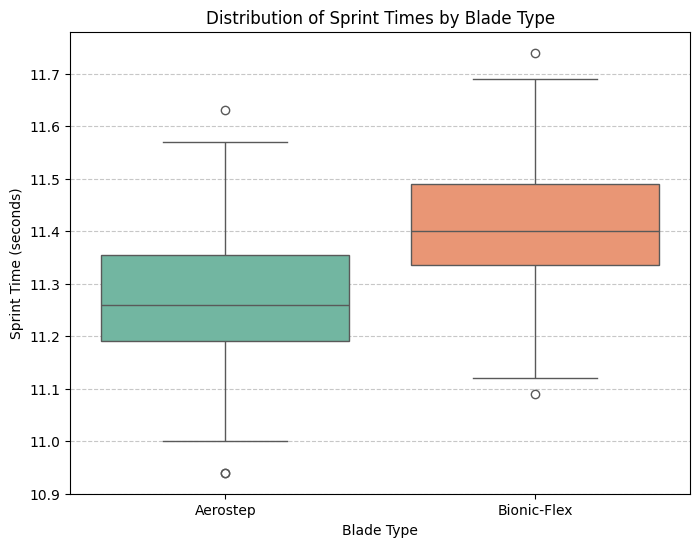

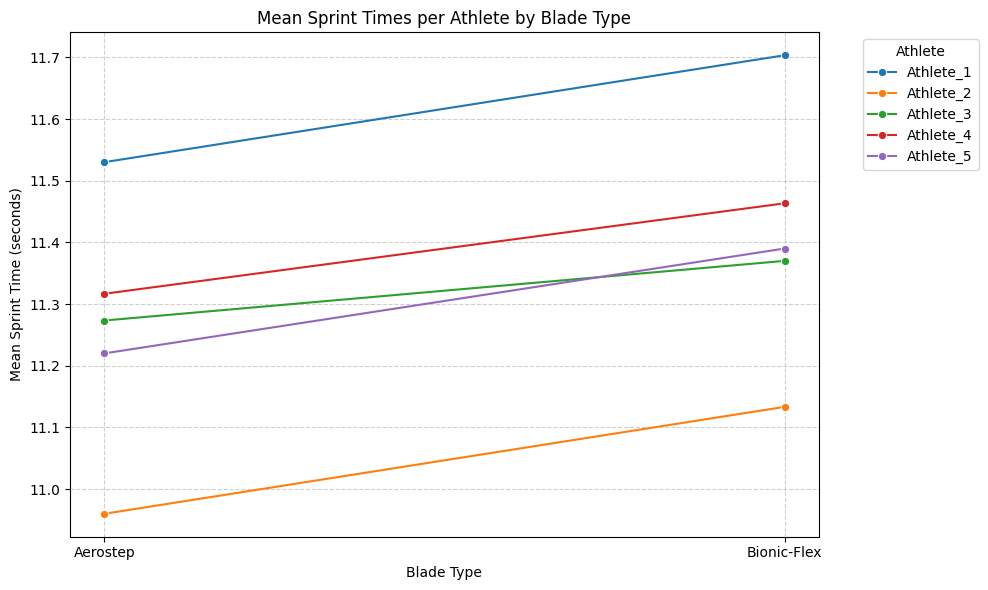

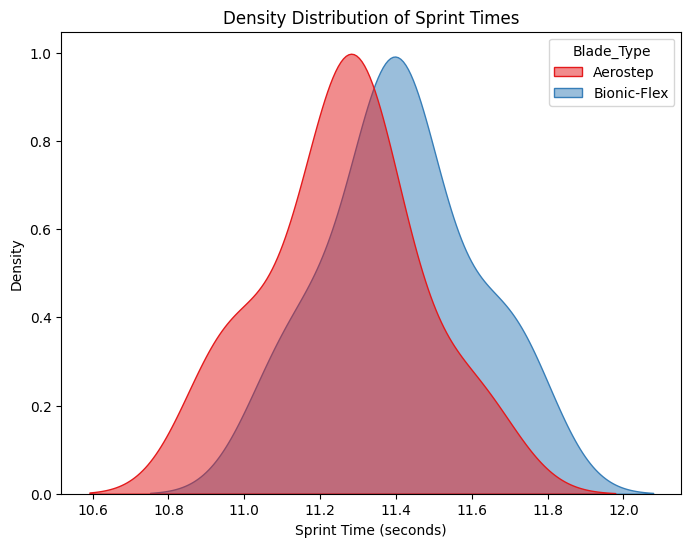


Mean Sprint Times:
Blade_Type
Aerostep       11.260
Bionic-Flex    11.412
Name: Sprint_Time, dtype: float64


In [27]:
## Question 6 Code ##

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
blade = pd.read_excel('/content/STAT-7220-Applied-Experimental-Design/Assignments/HW4/STAT Paralympic_Blade_Experiment.xlsx')

# Summary Statistics
summary_stats = blade.groupby('Blade_Type')['Sprint_Time'].describe()
print("Summary Statistics by Blade Type:")
print(summary_stats)

# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Blade_Type', y='Sprint_Time', data=blade, hue='Blade_Type', palette='Set2', legend=False)
plt.title('Distribution of Sprint Times by Blade Type')
plt.ylabel('Sprint Time (seconds)')
plt.xlabel('Blade Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
plt.close()

# Interaction Plot
athlete_blade_means = blade.groupby(['Athlete_ID', 'Blade_Type'])['Sprint_Time'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='Blade_Type', y='Sprint_Time', hue='Athlete_ID', data=athlete_blade_means, marker='o')
plt.title('Mean Sprint Times per Athlete by Blade Type')
plt.ylabel('Mean Sprint Time (seconds)')
plt.xlabel('Blade Type')
plt.legend(title='Athlete', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
plt.close()

# Distribution Comparison
plt.figure(figsize=(8, 6))
sns.kdeplot(data=blade, x='Sprint_Time', hue='Blade_Type', fill=True, alpha=0.5, palette='Set1')
plt.title('Density Distribution of Sprint Times')
plt.xlabel('Sprint Time (seconds)')
plt.ylabel('Density')
plt.show()
plt.close()

# Means
print("\nMean Sprint Times:")
print(blade.groupby('Blade_Type')['Sprint_Time'].mean())

- The alternative hypothesis ($H_a$) is highly supported by the findings of the exploratory analysis of the sprint data.

7. Fit the mixed effects model. Using the model residuals, check the assumption of normality using both a testing method and a visual method. Do we have support for the assumption of normality from the data? Why or why not?

                Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     Sprint_Time
No. Observations:     30          Method:                 REML       
No. Groups:           5           Scale:                  0.0034     
Min. group size:      6           Log-Likelihood:         28.3941    
Max. group size:      6           Converged:              Yes        
Mean group size:      6.0                                            
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                 11.260    0.092 122.543 0.000 11.080 11.440
Blade_Type[T.Bionic-Flex]  0.152    0.021   7.095 0.000  0.110  0.194
Group Var                  0.041    0.542                            


Shapiro-Wilk Test of Normality on Residuals:
Statistic: 0.9701, p-value: 0.5422


<Figure size 600x500 with 0 Axes>

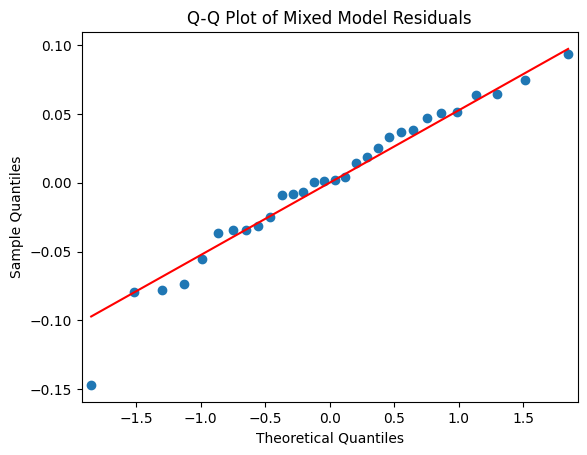

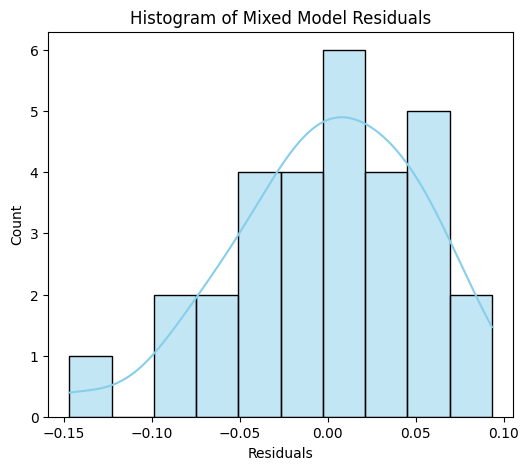

In [23]:
## Question 7 Code ##

import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt

# Fit the mixed effects model
# Sprint_Time ~ Blade_Type with a random intercept for Athlete_ID
blade_model = smf.mixedlm("Sprint_Time ~ Blade_Type", blade, groups=blade["Athlete_ID"])
model_fit = blade_model.fit()

print(model_fit.summary())

# Extract residuals
residuals = model_fit.resid

# Shapiro-Wilk test
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"\nShapiro-Wilk Test of Normality on Residuals:")
print(f"Statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.4f}")

# Q-Q Plot
plt.figure(figsize=(6, 5))
sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot of Mixed Model Residuals')
plt.tight_layout()
plt.show()
plt.close()

# Histogram with KDE
plt.figure(figsize=(6, 5))
import seaborn as sns
sns.histplot(residuals, kde=True, bins=10, color='skyblue')
plt.title('Histogram of Mixed Model Residuals')
plt.xlabel('Residuals')
plt.tight_layout()
plt.show()
plt.close()

- **The data provides compelling evidence for the assumption of normalcy**.

- The same conclusion is reached by both the statistical testing and the visual methods: The Shapiro-Wilk test yields a $p$-value of $0.54$, indicating that the residuals do not appear to defy the normalcy assumption. A distribution that closely resembles the bell curve of a normal distribution is displayed by the Q-Q plot and histogram. As a result, the mixed effects model's normalcy assumption is completely met.

8. **Using the visual method described in the lecture notes**, check the assumption of constant variance. Do we have support for the assumption of constant variance? Why or why not?

/tmp/ipykernel_1316/1015056450.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Athlete_ID', y='Std_Residuals', data=blade, ax=axes[0], palette='Set3')
/tmp/ipykernel_1316/1015056450.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Blade_Type', y='Std_Residuals', data=blade, ax=axes[1], palette='Set2')


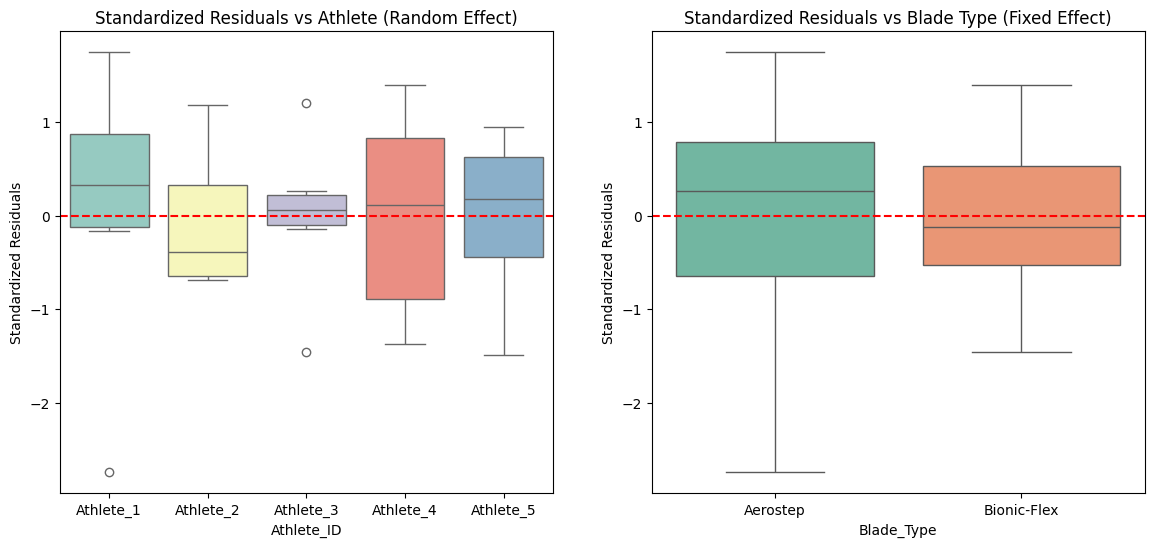

Variance by Athlete:
Athlete_ID
Athlete_1    2.377814
Athlete_2    0.584788
Athlete_3    0.732572
Athlete_4    1.273048
Athlete_5    0.818488
Name: Std_Residuals, dtype: float64

Variance by Blade Type:
Blade_Type
Aerostep       1.412842
Bionic-Flex    0.658586
Name: Std_Residuals, dtype: float64


In [28]:
## Question 8 Code ##

import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Fit the Linear Mixed Effects Model
blade_model = smf.mixedlm("Sprint_Time ~ Blade_Type", blade, groups=blade["Athlete_ID"])
result = blade_model.fit()

# Extract residuals
blade['Residuals'] = result.resid

# Standardize the residuals
blade['Std_Residuals'] = (blade['Residuals'] - blade['Residuals'].mean()) / blade['Residuals'].std()

# Plot Standardized Residuals vs Groups
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Standardized Residuals vs Random Effect (Athlete_ID)
sns.boxplot(x='Athlete_ID', y='Std_Residuals', data=blade, ax=axes[0], palette='Set3')
axes[0].set_title('Standardized Residuals vs Athlete (Random Effect)')
axes[0].set_ylabel('Standardized Residuals')
axes[0].axhline(0, color='red', linestyle='--')

# Standardized Residuals vs Fixed Effect (Blade_Type)
sns.boxplot(x='Blade_Type', y='Std_Residuals', data=blade, ax=axes[1], palette='Set2')
axes[1].set_title('Standardized Residuals vs Blade Type (Fixed Effect)')
axes[1].set_ylabel('Standardized Residuals')
axes[1].axhline(0, color='red', linestyle='--')
plt.show()
plt.close()

# Check variance for each group
variance_by_athlete = blade.groupby('Athlete_ID')['Std_Residuals'].var()
variance_by_blade = blade.groupby('Blade_Type')['Std_Residuals'].var()

# Display Result
print("Variance by Athlete:")
print(variance_by_athlete)
print("\nVariance by Blade Type:")
print(variance_by_blade)

- The assumption of constant variance is **sufficiently supported**. When analyzing these boxplots, we are searching for significant variations in spread, such as one box being enormous while the others are little, or a distinct systematic trend, such as variance steadily rising as the mean rises.

- We naturally anticipate some slight visual variation in the box sizes due to random sampling noise because our sample sizes are so limited. The assumption of constant variance is not significantly broken because there are no extreme outliers or significant differences in the distribution of the residuals among the various athletes or blade types, **so** The linear mixed-effects model is still suitable.

9. Report and interpret the result of the random effect. Which of the two hypotheses for the random effect are more strongly supported by the data?

In [24]:
## Question 9 Code ##

import pandas as pd
import statsmodels.formula.api as smf
import scipy.stats as stats

# Fit Full Model (Mixed Effects)
full_model = smf.mixedlm("Sprint_Time ~ Blade_Type", blade, groups=blade["Athlete_ID"]).fit()
llf_full = full_model.llf

# Fit Reduced Model (no random effect)
reduced_model = smf.ols("Sprint_Time ~ Blade_Type", blade).fit()
llf_reduced = reduced_model.llf

# Likelihood Ratio Test
lr_stat = -2 * (llf_reduced - llf_full)
p_value = stats.chi2.sf(lr_stat, 1) / 2

print(f"Full Model Log-Likelihood: {llf_full}")
print(f"Reduced Model Log-Likelihood: {llf_reduced}")
print(f"LR Test Statistic: {lr_stat}")
print(f"P-value: {p_value}")
print(f"Group Variance (Athlete): {full_model.cov_re.iloc[0,0]}")

Full Model Log-Likelihood: 28.394107855299097
Reduced Model Log-Likelihood: 7.267082504026941
LR Test Statistic: 42.25405070254431
P-value: 4.0076910625612684e-11
Group Variance (Athlete): 0.041067543204315576


- **The data overwhelmingly support the Alternative Hypothesis ($H_a$)**.

- The amount of variation in the 100-meter sprint times that may be attributed to the individual athletes' baseline differences is represented by the variance component of $0.041$. To put another way, athletes' baseline sprint speeds range from the overall average due to their inherent differences in physical capabilities, training histories, and biomechanics. We can effectively removeing the noise resulting from individual athlete differences by dividing this variance. This makes the data easier to understand, enabling us to more precisely identify and quantify the actual influence of the blade designs.

- We reject the null hypothesis because the Likelihood Ratio test's p-value is very little (p < .001). We infer that $\sigma^2_{\text{athlete}} > 0$ based on these results. This demonstrates that individual variability is highly relevant and that the appropriate and essential method for assessing this experiment was to use a mixed-effects model, or even a randomized block design.

10. Report and interpret the result of the fixed effect. Which of the two hypotheses for the fixed effect are more strongly supported by the data?

In [25]:
## Question 10 Code ##

import pandas as pd
import statsmodels.formula.api as smf

# Fit the Linear Mixed Effects Model
model = smf.mixedlm("Sprint_Time ~ Blade_Type", blade, groups=blade["Athlete_ID"])
result = model.fit()

# Display the full summary (
print(result.summary())

# Extract only the fixed effect coefficients
print("\nFixed Effect Coefficients:")
print(result.fe_params)

# extract p-values for the fixed effects
print("\nFixed Effect P-values:")
print(result.pvalues)

                Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     Sprint_Time
No. Observations:     30          Method:                 REML       
No. Groups:           5           Scale:                  0.0034     
Min. group size:      6           Log-Likelihood:         28.3941    
Max. group size:      6           Converged:              Yes        
Mean group size:      6.0                                            
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                 11.260    0.092 122.543 0.000 11.080 11.440
Blade_Type[T.Bionic-Flex]  0.152    0.021   7.095 0.000  0.110  0.194
Group Var                  0.041    0.542                            


Fixed Effect Coefficients:
Intercept                    11.260
Blade_Type[T.Bionic-Flex]     0.152
dtype

- **The data overwhelmingly support the Alternative Hypothesis ($H_a$)**.

Alternative Hypothesis ($H_a$): $\mu_{\text{Aerostep}} \neq \mu_{\text{Bionic-Flex}}$ (There is a significant difference in mean sprint times).

- After taking into consideration the athletes' random variability, the fixed effect calculates the average difference in 100-meter sprint timings between the two blade types. The baseline (the intercept, which was $11.260$ seconds) in this model is the Aerostep blade. The Bionic-Flex blade has a coefficient of $+0.152$. This indicates that when an athlete uses the Bionic-Flex blade instead of the Aerostep blade, their sprint time is, on average, $0.152$ seconds slower. This data suggests that the Aerostep design offers a clear performance advantage over the Bionic-Flex design because shorter times are better when sprinting.

- We can readily reject the null hypothesis because the p-value ($< 0.001$) is significantly below the conventional alpha threshold of $0.05$. The results show that there is a considerable difference in the mean 100-meter sprint times between the two carbon-fiber blade designs, with the Aerostep model being the faster blade.

11. Finally, provide a brief contextual conclusion for this experiment. Discuss experiment limitations and future directions.

- The experiment's findings show that there is a performance difference between the two carbon-fiber blade designs that is both statistically significant and contextually significant. The Aerostep (Model A) regularly beat the Bionic-Flex (Model B), producing an average improvement of 0.152 seconds after accounting for the inherent variability between individual T64 sprinters. A 0.15-second edge is very significant in professional sprinting, where the gap between gold and silver is frequently measured in hundredths of a second. For this particular athlete class, the Aerostep design seems to be the best equipment option for optimizing 100-meter sprint velocity.

**Limitations**

- The study relied on a small group of five athletes. While sufficient for a repeated-measures design, a larger sample would provide greater confidence in the generalizability of the results across the entire T64 population.

- The experiment only measured 100-meter sprint times. It does not account for long-term durability of the blades or how they might perform in different race lengths like the 200m or 400m.

**Future Directions**

- Future testing should include indoor vs. outdoor tracks and different weather scenarios to ensure the blade performs reliably in all competitive environments.

- Monitoring athlete performance over a full competitive season would help determine if the performance gains are sustainable or if they change as the athlete becomes more "attuned" to the specific flex characteristics of a blade.